In [1]:
import pandas as pd
import matplotlib.pyplot as plt 

In [3]:
df = pd.read_csv("../benchmark/data/heart/heart.csv", delimiter=",")

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [18]:
df["target"].value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [5]:
df["sex"].value_counts()

sex
1    713
0    312
Name: count, dtype: int64

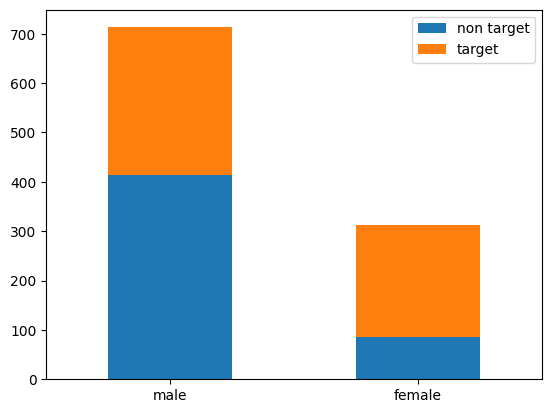

In [9]:
target = df[df['target'] == 1]
man_target = len(target[target['sex'] == 1].index)
woman_target = len(target[target['sex'] == 0].index)

non_target = df[df['target'] == 0]
man_non_target = len(non_target[non_target['sex'] == 1].index)
woman_non_target = len(non_target[non_target['sex'] == 0].index)


res_df = pd.DataFrame(
    {
        'non target': [man_non_target, woman_non_target],
        'target': [man_target, woman_target],
    },
    index=['male', 'female']
)

res_df.plot(kind='bar', stacked=True)#, color=['red', 'pink'])
plt.legend(loc="upper right")
plt.xticks(rotation=0)
plt.show()

<Axes: >

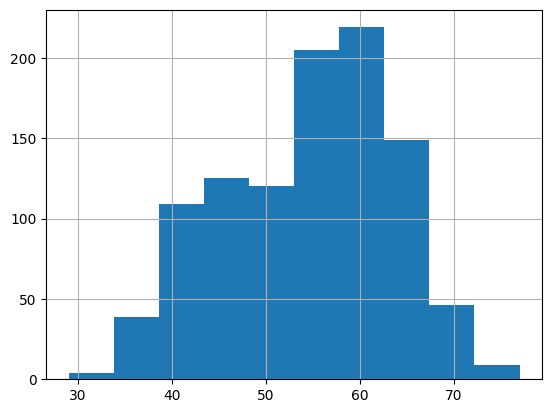

In [10]:
df["age"].hist()

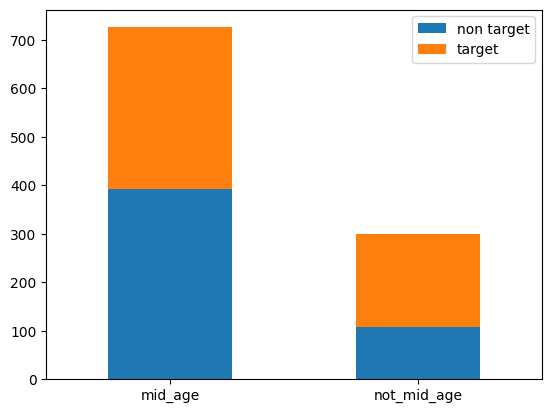

In [17]:
target = df[df['target'] == 1]
mid_age_target = len(target[(target['age'] >= 45) & (target['age'] <= 65)].index)
non_mid_agetarget = len(target[(target['age'] < 45) | (target['age'] > 65)].index)

non_target = df[df['target'] == 0]
mid_age_non_target = len(non_target[(non_target['age'] >= 45) & (non_target['age'] <= 65)].index)
non_mid_agenon_target = len(non_target[(non_target['age'] < 45) | (non_target['age'] > 65)].index)


res_df = pd.DataFrame(
    {
        'non target': [mid_age_non_target, non_mid_agenon_target],
        'target': [mid_age_target, non_mid_agetarget],
    },
    index=['mid_age', 'not_mid_age']
)

res_df.plot(kind='bar', stacked=True)#, color=['red', 'pink'])
plt.legend(loc="upper right")
plt.xticks(rotation=0)
plt.show()